In [1]:
import numpy as np
import argparse
import yaml

import tabsim
from tabsim.config import load_config, load_obs, get_telescope_definitions, deep_update
from analytical_satsky import load_constellation
from analytical_satsky.shell_obs import IntegralObsModel

from astropy.time import Time
import astropy.units as u

import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
config = 'data/test_config.yaml'
with open(config) as f:
    yaml_config = yaml.safe_load(f)

##########
# TABSIM # 
##########
#use tabsim only to manage time coherently
obs_config = load_config(config)
tel_def = get_telescope_definitions(obs_config["telescope"]["name"])
obs_config["telescope"] = deep_update(obs_config["telescope"], tel_def)
print("start LHA", obs_config["observation"]["start_time_lha"])
obs = load_obs(obs_config)
t_mid = np.argmin(np.abs(obs.times_fine.compute()))

#####################
# Analytical Satsky # 
#####################
satcons_df = load_constellation(*yaml_config["satcat_sampling"]["constellations"])

ndec, nra = yaml_config["satcat_sampling"]["ndec"], yaml_config["satcat_sampling"]["nra"]
npoints = yaml_config["satcat_sampling"]["npoints"]
Lfov = (yaml_config["satcat_sampling"]["Lfov"]*u.deg).to(u.rad)
obs_init_mjd = Time(obs.times_mjd_fine.compute()[t_mid], format='mjd')
obs_end_mjd = Time(obs.times_mjd_fine.compute()[-1], format='mjd')
t_exp_mjd = (obs_end_mjd - obs_init_mjd).to(u.day).value
print(f"Observation duration: {t_exp_mjd:.2f} days")
dt = yaml_config["satcat_sampling"]["dt"] * u.s

integral_obs_model = IntegralObsModel(obs, satcons_df, Lfov, t_exp_mjd, obs_init_mjd, ndec, nra, npoints, dt)
satellite_catalogue = integral_obs_model.sample_satellites(seed=yaml_config["satcat_sampling"]["seed"])

start LHA 0.0

Theoretical synthesized beam width : 126 arcsec
Observation duration: 0.04 days


In [3]:
satellite_catalogue

,N,i,h,long_asc_node,periapsis,decstart,rastart,tstart,towards
0,1,46.0,345.0,56.178992,-42.168313,-0.5546761538509482 rad,0.45271436096020984 rad,45.125211,N
1,1,53.0,550.0,49.569178,-41.777591,-0.5484907430240424 rad,0.44277302074450714 rad,110.306071,N
2,1,43.0,530.0,60.286451,-52.630822,-0.5355218608207445 rad,0.4332238975100662 rad,170.473018,N
3,1,46.0,345.0,56.577475,-51.268456,-0.530982927766056 rad,0.43175916173684403 rad,185.514755,N
4,1,38.0,350.0,68.181564,-61.112025,-0.5579154678180451 rad,0.47869333302288386 rad,205.570405,N
...,...,...,...,...,...,...,...,...,...
72,1,70.0,570.0,208.822935,-4.692542,-0.5003219168938831 rad,0.4413989809446221 rad,3419.488194,S
73,1,70.0,570.0,209.247718,-8.838389,-0.4887030009886896 rad,0.4722321991988255 rad,3484.669054,S
74,1,43.0,530.0,73.390002,-262.274481,-0.5509067935990994 rad,0.4459290139262391 rad,3494.696878,N
75,1,43.0,530.0,187.254329,-1.740806,-0.48954038994671145 rad,0.47998645647579574 rad,3544.836001,S


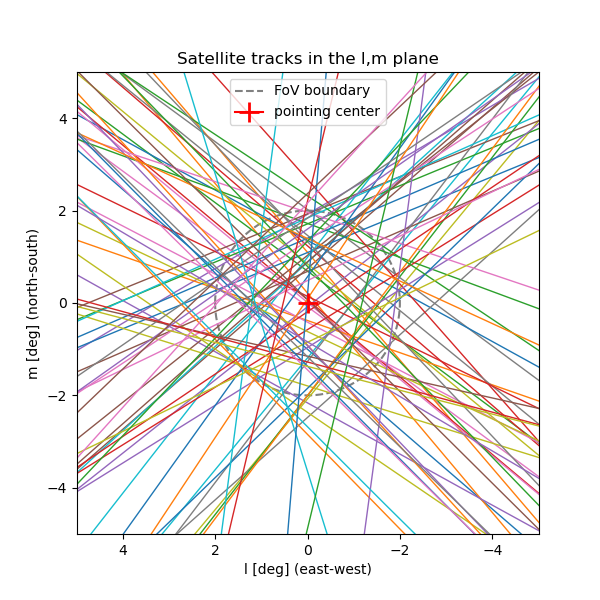

In [4]:
from analytical_satsky.plot_utils import plot_satellite_tracks_lm

plot_satellite_tracks_lm(integral_obs_model, satellite_catalogue)